In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [2]:
RESEARCH_DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
RESEARCH_MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESEARCH_RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 03 Evaluate

This notebook loads the trained model, runs sequential inference, computes anomaly scores and reconstruction errors, evaluates early detection, and saves outputs under `results/research_smoke_auto/`.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import EvalConfig
from src.evaluate import evaluate_model
from src.utils import read_json

## Sequential Inference And Anomaly Score Calculation

In [4]:
cfg = EvalConfig(
    dataset_dir=RESEARCH_DATASET_DIR,
    model_dir=RESEARCH_MODEL_DIR,
    output_dir=RESEARCH_RESULTS_DIR,
    split="test",
    top_k_features=5,
    use_synthetic_injection=True,
    include_gpt_in_stream=True,
    telegram_enabled=True,
)
eval_summary = evaluate_model(cfg)
eval_summary["evaluation_summary"]

{'threshold': 4.4031548500061035,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'pr_auc': 1.8518309064464394e-05,
 'roc_auc': 0.6646219411883049,
 'num_windows': 392681,
 'num_positive_windows': 4,
 'num_realtime_alerts': 1813,
 'num_gpt_decisions': 1813,
 'split': 'test',
 'telegram_notifications_sent': 20,
 'telegram_notifications_failed': 0}

In [5]:
predictions = pd.read_csv(cfg.output_dir / "window_level_predictions.csv")
predictions.head()

,window_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,top_feature_rank,top_k_features,top_k_feature_errors,label,predicted_label,event_id
0,0,unknown_container,unknown_machine,0,test,0.063017,4.403155,-4.340138,"[0.051976047456264496, 0.0020141222048550844, ...","[7, 0, 1, 5, 2, 6, 3, 4]","['disk_io', 'cpu_util', 'mem_util', 'net_in', ...","[0.4499579668045044, 0.051976047456264496, 0.0...",0,0,-1
1,1,unknown_container,unknown_machine,1,test,0.130804,4.403155,-4.272351,"[0.06948301196098328, 0.0018997415900230408, 4...","[7, 0, 1, 5, 6, 2, 3, 4]","['disk_io', 'cpu_util', 'mem_util', 'net_in', ...","[0.9733790159225464, 0.06948301196098328, 0.00...",0,0,-1
2,2,unknown_container,unknown_machine,2,test,0.187592,4.403155,-4.215563,"[0.12418682873249054, 0.0017895243363454938, 8...","[7, 0, 1, 5, 6, 2, 3, 4]","['disk_io', 'cpu_util', 'mem_util', 'net_in', ...","[1.3737372159957886, 0.12418682873249054, 0.00...",0,0,-1
3,3,unknown_container,unknown_machine,3,test,0.060229,4.403155,-4.342926,"[0.07659731805324554, 0.0011934166541323066, 5...","[7, 0, 1, 5, 6, 2, 3, 4]","['disk_io', 'cpu_util', 'mem_util', 'net_in', ...","[0.40320685505867004, 0.07659731805324554, 0.0...",0,0,-1
4,4,unknown_container,unknown_machine,4,test,0.077238,4.403155,-4.325917,"[0.04895187169313431, 0.002004738198593259, 4....","[7, 0, 1, 5, 6, 2, 3, 4]","['disk_io', 'cpu_util', 'mem_util', 'net_in', ...","[0.566692054271698, 0.04895187169313431, 0.002...",0,0,-1


## Feature-Wise Reconstruction Error And Top-k Anomalous Features

In [6]:
predictions[
    [
        "window_id",
        "container_id",
        "anomaly_score",
        "top_k_features",
        "top_k_feature_errors",
    ]
].sort_values("anomaly_score", ascending=False).head(10)

,window_id,container_id,anomaly_score,top_k_features,top_k_feature_errors
293265,293265,unknown_container,27.277042,"['mem_gps', 'mpki', 'cpu_util', 'disk_io', 'cpi']","[202.0413360595703, 12.68392562866211, 1.40792..."
113525,113525,unknown_container,26.608438,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[206.02357482910156, 4.51305627822876, 0.98595..."
127987,127987,unknown_container,24.769840,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[191.6338348388672, 4.7525434494018555, 0.7187..."
107091,107091,unknown_container,23.854710,"['mem_gps', 'mpki', 'cpi', 'cpu_util', 'disk_io']","[185.00877380371094, 3.4412927627563477, 1.090..."
91652,91652,unknown_container,23.327656,"['mem_gps', 'mpki', 'cpu_util', 'disk_io', 'cpi']","[180.22317504882812, 4.043589115142822, 0.9098..."
305586,305586,unknown_container,22.616074,"['mem_gps', 'mpki', 'disk_io', 'cpu_util', 'cpi']","[163.96145629882812, 13.775984764099121, 1.241..."
87244,87244,unknown_container,21.480433,"['mem_gps', 'mpki', 'cpu_util', 'disk_io', 'cpi']","[166.98951721191406, 3.348172664642334, 0.6055..."
152574,152574,unknown_container,20.971233,"['mem_gps', 'disk_io', 'cpi', 'cpu_util', 'mem...","[162.49853515625, 2.0989203453063965, 1.459157..."
143355,143355,unknown_container,20.851479,"['mem_gps', 'mpki', 'disk_io', 'cpi', 'cpu_util']","[150.53848266601562, 14.592707633972168, 0.810..."
173768,173768,unknown_container,20.802483,"['mem_gps', 'disk_io', 'cpi', 'cpu_util', 'mem...","[162.01593017578125, 2.1333558559417725, 0.733..."


## Precision, Recall, F1, PR-AUC, And ROC-AUC

In [7]:
evaluation_summary = read_json(cfg.output_dir / "evaluation_summary.json")
evaluation_summary

{'threshold': 4.4031548500061035,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'pr_auc': 1.8518309064464394e-05,
 'roc_auc': 0.6646219411883049,
 'num_windows': 392681,
 'num_positive_windows': 4,
 'num_realtime_alerts': 1813,
 'num_gpt_decisions': 1813,
 'split': 'test',
 'telegram_notifications_sent': 20,
 'telegram_notifications_failed': 0}

## Strict And Relaxed Early Detection Evaluation

In [8]:
event_metrics = read_json(cfg.output_dir / "event_metrics.json")
event_metrics

{'num_events': 1,
 'strict_detection_rate': 0.0,
 'relaxed_detection_rate': 0.0,
 'mean_detection_delay': None}

## Streaming-Style Inference Flow

In [9]:
realtime_stream = pd.read_csv(cfg.output_dir / "realtime_stream_predictions.csv")
realtime_stream.head()

,window_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,top_feature_rank,...,predicted_label,event_id,realtime_step,alert_ready,gpt_triggered,gpt_label,gpt_severity,gpt_recommended_action,gpt_explanation,compact_anomaly_summary
0,0,unknown_container,unknown_machine,0,test,0.063017,4.403155,-4.340138,"[0.051976047456264496, 0.0020141222048550844, ...","[7, 0, 1, 5, 2, 6, 3, 4]",...,0,-1,0,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 0, ""container_id"": ""unknown_cont..."
1,1,unknown_container,unknown_machine,1,test,0.130804,4.403155,-4.272351,"[0.06948301196098328, 0.0018997415900230408, 4...","[7, 0, 1, 5, 6, 2, 3, 4]",...,0,-1,1,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 1, ""container_id"": ""unknown_cont..."
2,2,unknown_container,unknown_machine,2,test,0.187592,4.403155,-4.215563,"[0.12418682873249054, 0.0017895243363454938, 8...","[7, 0, 1, 5, 6, 2, 3, 4]",...,0,-1,2,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 2, ""container_id"": ""unknown_cont..."
3,3,unknown_container,unknown_machine,3,test,0.060229,4.403155,-4.342926,"[0.07659731805324554, 0.0011934166541323066, 5...","[7, 0, 1, 5, 6, 2, 3, 4]",...,0,-1,3,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 3, ""container_id"": ""unknown_cont..."
4,4,unknown_container,unknown_machine,4,test,0.077238,4.403155,-4.325917,"[0.04895187169313431, 0.002004738198593259, 4....","[7, 0, 1, 5, 6, 2, 3, 4]",...,0,-1,4,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 4, ""container_id"": ""unknown_cont..."


## Visualizations

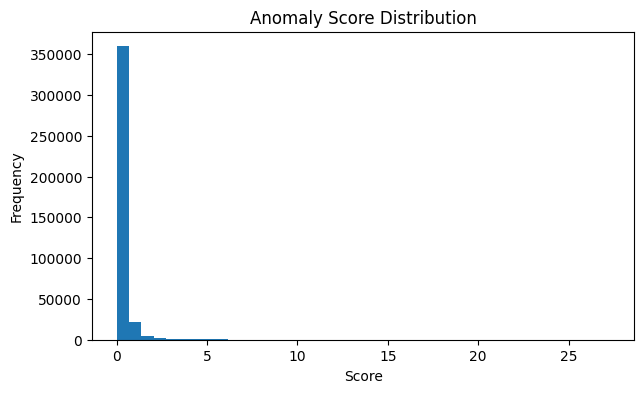

In [10]:
plt.figure(figsize=(7, 4))
predictions["anomaly_score"].plot(kind="hist", bins=40)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.show()

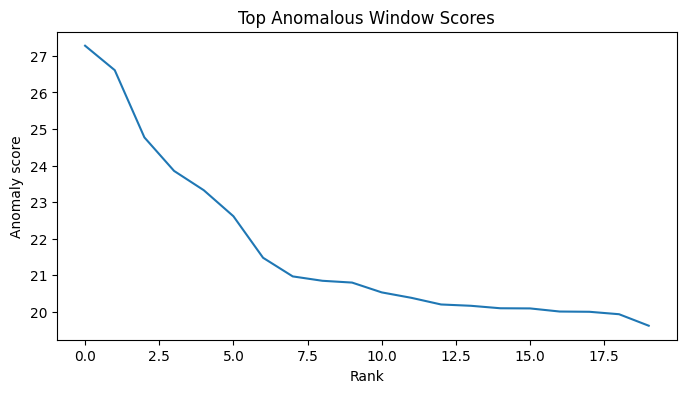

In [11]:
top_windows = pd.read_csv(cfg.output_dir / "top_anomalous_windows.csv")
plt.figure(figsize=(8, 4))
plt.plot(top_windows["anomaly_score"].head(20).to_numpy())
plt.title("Top Anomalous Window Scores")
plt.xlabel("Rank")
plt.ylabel("Anomaly score")
plt.show()